In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import Utils as utils
import FGSM as fgsm
import PGD as pgd
import boundary as boundary
from tensorflow.keras.models import load_model


## Fast Gradient Sign Method (FGSM)

### Overview
FGSM is an adversarial attack technique that creates perturbed inputs to mislead deep learning models. It leverages the gradient of the loss function to generate adversarial examples efficiently.

### Formula
Given:
- `x`: Input  
- `y`: True label  
- `J`: Loss function  
- `epsilon (ε)`: Perturbation magnitude  

The adversarial example `x_adv` is defined as:

x_adv = x + ε * sign(∇_x J(θ, x, y))

### Key Idea
FGSM adds a small perturbation in the direction of the gradient to maximize the model's error.

In [ ]:
!pip install gdown  # Install gdown if not available
!gdown "https://drive.google.com/uc?id=1vnILayXgxpPRKrgqWfQXsCrub6G4ywHR"


Downloading...
From (original): https://drive.google.com/uc?id=1vnILayXgxpPRKrgqWfQXsCrub6G4ywHR
From (redirected): https://drive.google.com/uc?id=1vnILayXgxpPRKrgqWfQXsCrub6G4ywHR&confirm=t&uuid=b90604bf-4808-489e-a4aa-2084b9b6f52f
To: /content/TrafficSigns_EfficientNetB1.keras
100% 80.4M/80.4M [00:02<00:00, 27.5MB/s]


In [ ]:
#load the model

model = load_model('TrafficSigns_EfficientNetB1.keras')


In [ ]:
# Direct download from original source (Institut für Neuroinformatik)
!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip

# Unzip both files
!unzip GTSRB_Final_Training_Images.zip
!unzip GTSRB_Final_Test_Images.zip

# Cleanup (optional)
!rm *.zip

print("Dataset downloaded and extracted!")

Streaming output truncated to the last 5000 lines.
  inflating: GTSRB/Final_Test/Images/07633.ppm  
  inflating: GTSRB/Final_Test/Images/07634.ppm  
  inflating: GTSRB/Final_Test/Images/07635.ppm  
  inflating: GTSRB/Final_Test/Images/07636.ppm  
  inflating: GTSRB/Final_Test/Images/07637.ppm  
  inflating: GTSRB/Final_Test/Images/07638.ppm  
  inflating: GTSRB/Final_Test/Images/07639.ppm  
  inflating: GTSRB/Final_Test/Images/07640.ppm  
  inflating: GTSRB/Final_Test/Images/07641.ppm  
  inflating: GTSRB/Final_Test/Images/07642.ppm  
  inflating: GTSRB/Final_Test/Images/07643.ppm  
  inflating: GTSRB/Final_Test/Images/07644.ppm  
  inflating: GTSRB/Final_Test/Images/07645.ppm  
  inflating: GTSRB/Final_Test/Images/07646.ppm  
  inflating: GTSRB/Final_Test/Images/07647.ppm  
  inflating: GTSRB/Final_Test/Images/07648.ppm  
  inflating: GTSRB/Final_Test/Images/07649.ppm  
  inflating: GTSRB/Final_Test/Images/07650.ppm  
  inflating: GTSRB/Final_Test/Images/07651.ppm  
  inflating: GTSRB

In [ ]:
#load the test data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_dir = "GTSRB/Final_Training/Images"  # Path to training folder
test_dir = "GTSRB/Final_Test/Images"    # Path to testing folder
batch_size = 32
target_size = (240, 240)


# Generator for testing (no augmentation, no split)
test_datagen = ImageDataGenerator(
    validation_split = 0.1
)

# Test generator (from test folder - no subsetting)
test_generator = test_datagen.flow_from_directory(
    data_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="sparse",
    subset="validation",
    shuffle=False  # Keep test data in original order
)


Found 3920 images belonging to 43 classes.


In [ ]:
# GTSRB Class ID to Sign Name Mapping (43 classes)
GTSRB_CLASSES = {
    0: "Speed limit 20",
    1: "Speed limit 30",
    2: "Speed limit 50",
    3: "Speed limit 60",
    4: "Speed limit 70",
    5: "Speed limit 80",
    6: "End of speed limit 80",
    7: "Speed limit 100",
    8: "Speed limit 120",
    9: "No passing",
    10: "No passing for vehicles over 3.5 tons",
    11: "Right-of-way at next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve left",
    20: "Dangerous curve right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing for vehicles over 3.5 tons"
}

In [ ]:

def predict_traffic_sign(img_input, model, class_mapping=GTSRB_CLASSES):
    """
    Accepts either:
    - Tensor (rank 3/4)
    - Bytes (raw image bytes)
    - File path (string)
    """

    prop = model.predict(img_input)
    print(prop.shape)
    class_id = np.argmax(prop)
    class_name = class_mapping[class_id]
    return  class_name, prop[0][class_id]

In [ ]:
import numpy as np

# Store predictions and true labels
predicted_labels = []
true_labels = []

# Loop through all batches in the test set
for i in range(len(test_generator)):
    img_batch, label_batch = test_generator[i]  # Get a batch of images and labels

    # Process each image in the batch
    for j in range(len(img_batch)):
        img = img_batch[j]  # Get image
        img_input = np.expand_dims(img, axis=0)  # Convert (240, 240, 3) → (1, 240, 240, 3)
        true_label = label_batch[j]  # True class index

        # Predict class
        predicted_class, confidence = predict_traffic_sign(img_input, model, GTSRB_CLASSES)

        # Store results
        predicted_labels.append(predicted_class)
        true_labels.append(GTSRB_CLASSES[true_label])  # Convert index to class name

# Convert lists to NumPy arrays for easier processing
predicted_labels = np.array(predicted_labels)
true_labels = np.array(true_labels)


Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Test Accuracy: {accuracy*100:.2f}%")


Test Accuracy: 96.02%


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, predicted_labels))


                                              precision    recall  f1-score   support

                                  Ahead only       1.00      1.00      1.00       120
                          Beware of ice/snow       1.00      0.91      0.95        45
                           Bicycles crossing       1.00      0.41      0.58        27
                                  Bumpy road       1.00      1.00      1.00        39
                           Children crossing       1.00      1.00      1.00        54
                        Dangerous curve left       1.00      0.33      0.50        21
                       Dangerous curve right       1.00      1.00      1.00        36
                                Double curve       1.00      1.00      1.00        33
         End of all speed and passing limits       1.00      0.33      0.50        24
                           End of no passing       1.00      0.17      0.29        24
End of no passing for vehicles over 3.5 tons       0.

In [ ]:
np.savez("predictions.npz", predicted_labels=predicted_labels, true_labels=true_labels)


In [ ]:
#load the test data results
data = np.load("predictions.npz")
predicted_labels = data["predicted_labels"]
true_labels = data["true_labels"]


In [ ]:
# Set attack strength (adjust as needed)
EPSILON = 0.01

# Store adversarial images and true labels
adversarial_images = []
true_labels = []

for j in range(len(test_generator)):
    img_batch, label_batch = test_generator[j]  # Get a batch of images and labels
    for i in range(len(img_batch)):
        adv_img = fgsm.fgsm_attack_single_image(model, img_batch[i], label_batch[i], EPSILON,normalized=False)
        adversarial_images.append(adv_img)
        true_labels.append(label_batch[i])

    print(f"Batch {j+1}/{len(test_generator)} completed")

# Convert lists to NumPy arrays for easier processing
adversarial_images = np.array(adversarial_images)
true_labels = np.array(true_labels)

#save the adversarial images
np.savez("adversarial_images.npz", adversarial_images=adversarial_images, true_labels=true_labels)

Batch 1/123 completed
Batch 2/123 completed
Batch 3/123 completed
Batch 4/123 completed
Batch 5/123 completed
Batch 6/123 completed
Batch 7/123 completed
Batch 8/123 completed
Batch 9/123 completed
Batch 10/123 completed
Batch 11/123 completed
Batch 12/123 completed
Batch 13/123 completed
Batch 14/123 completed
Batch 15/123 completed
Batch 16/123 completed
Batch 17/123 completed
Batch 18/123 completed
Batch 19/123 completed
Batch 20/123 completed
Batch 21/123 completed
Batch 22/123 completed
Batch 23/123 completed
Batch 24/123 completed
Batch 25/123 completed
Batch 26/123 completed
Batch 27/123 completed
Batch 28/123 completed
Batch 29/123 completed
Batch 30/123 completed
Batch 31/123 completed
Batch 32/123 completed
Batch 33/123 completed
Batch 34/123 completed
Batch 35/123 completed
Batch 36/123 completed
Batch 37/123 completed
Batch 38/123 completed
Batch 39/123 completed
Batch 40/123 completed
Batch 41/123 completed
Batch 42/123 completed
Batch 43/123 completed
Batch 44/123 complet

In [ ]:

# Load adversarial images
adversarial_data = np.load("adversarial_images.npz")
adversarial_images = adversarial_data['adversarial_images']
true_labels = adversarial_data['true_labels']

# Store predictions
predicted_labels = []

# Loop through all adversarial images
for i in range(len(adversarial_images)):
    img = adversarial_images[i]
    img_input = np.expand_dims(img, axis=0)  # Convert to batch format

    # Predict class (assuming you have a similar predict function)
    predicted_class, confidence = predict_traffic_sign(img_input, model, GTSRB_CLASSES)

    # Store results
    predicted_labels.append(predicted_class)

# Convert to NumPy array
predicted_labels = np.array(predicted_labels)



Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
(1, 43)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4

In [ ]:
labels_str =  [GTSRB_CLASSES[label] for label in true_labels]

In [ ]:
np.savez("Adv_predictions.npz", predicted_labels=predicted_labels, true_labels=labels_str)


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print(accuracy_score(labels_str, predicted_labels))

0.41785714285714287


In [ ]:
# Generate classification report
print(classification_report(labels_str, predicted_labels))

                                              precision    recall  f1-score   support

                                  Ahead only       0.74      0.58      0.65       120
                          Beware of ice/snow       0.31      0.24      0.27        45
                           Bicycles crossing       0.00      0.00      0.00        27
                                  Bumpy road       0.38      0.67      0.48        39
                           Children crossing       0.45      0.28      0.34        54
                        Dangerous curve left       0.00      0.00      0.00        21
                       Dangerous curve right       0.02      0.03      0.02        36
                                Double curve       0.57      0.48      0.52        33
         End of all speed and passing limits       0.00      0.00      0.00        24
                           End of no passing       0.00      0.00      0.00        24
End of no passing for vehicles over 3.5 tons       0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
adv_FGSM = np.load("adversarial_images.npz")
adv_images = adv_FGSM['adversarial_images']
predictions = np.load("Adv_predictions.npz")
pred_labels = predictions['predicted_labels']
true_labels = predictions['true_labels']



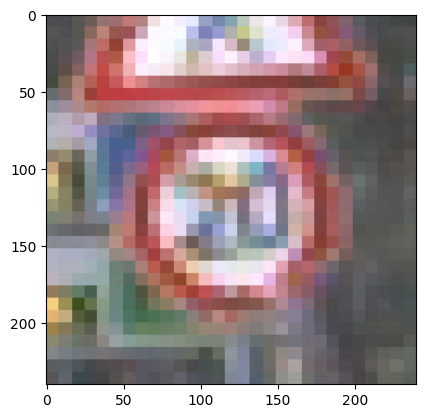

In [ ]:
plt.imshow(adv_images[0]/255)
plt.show()

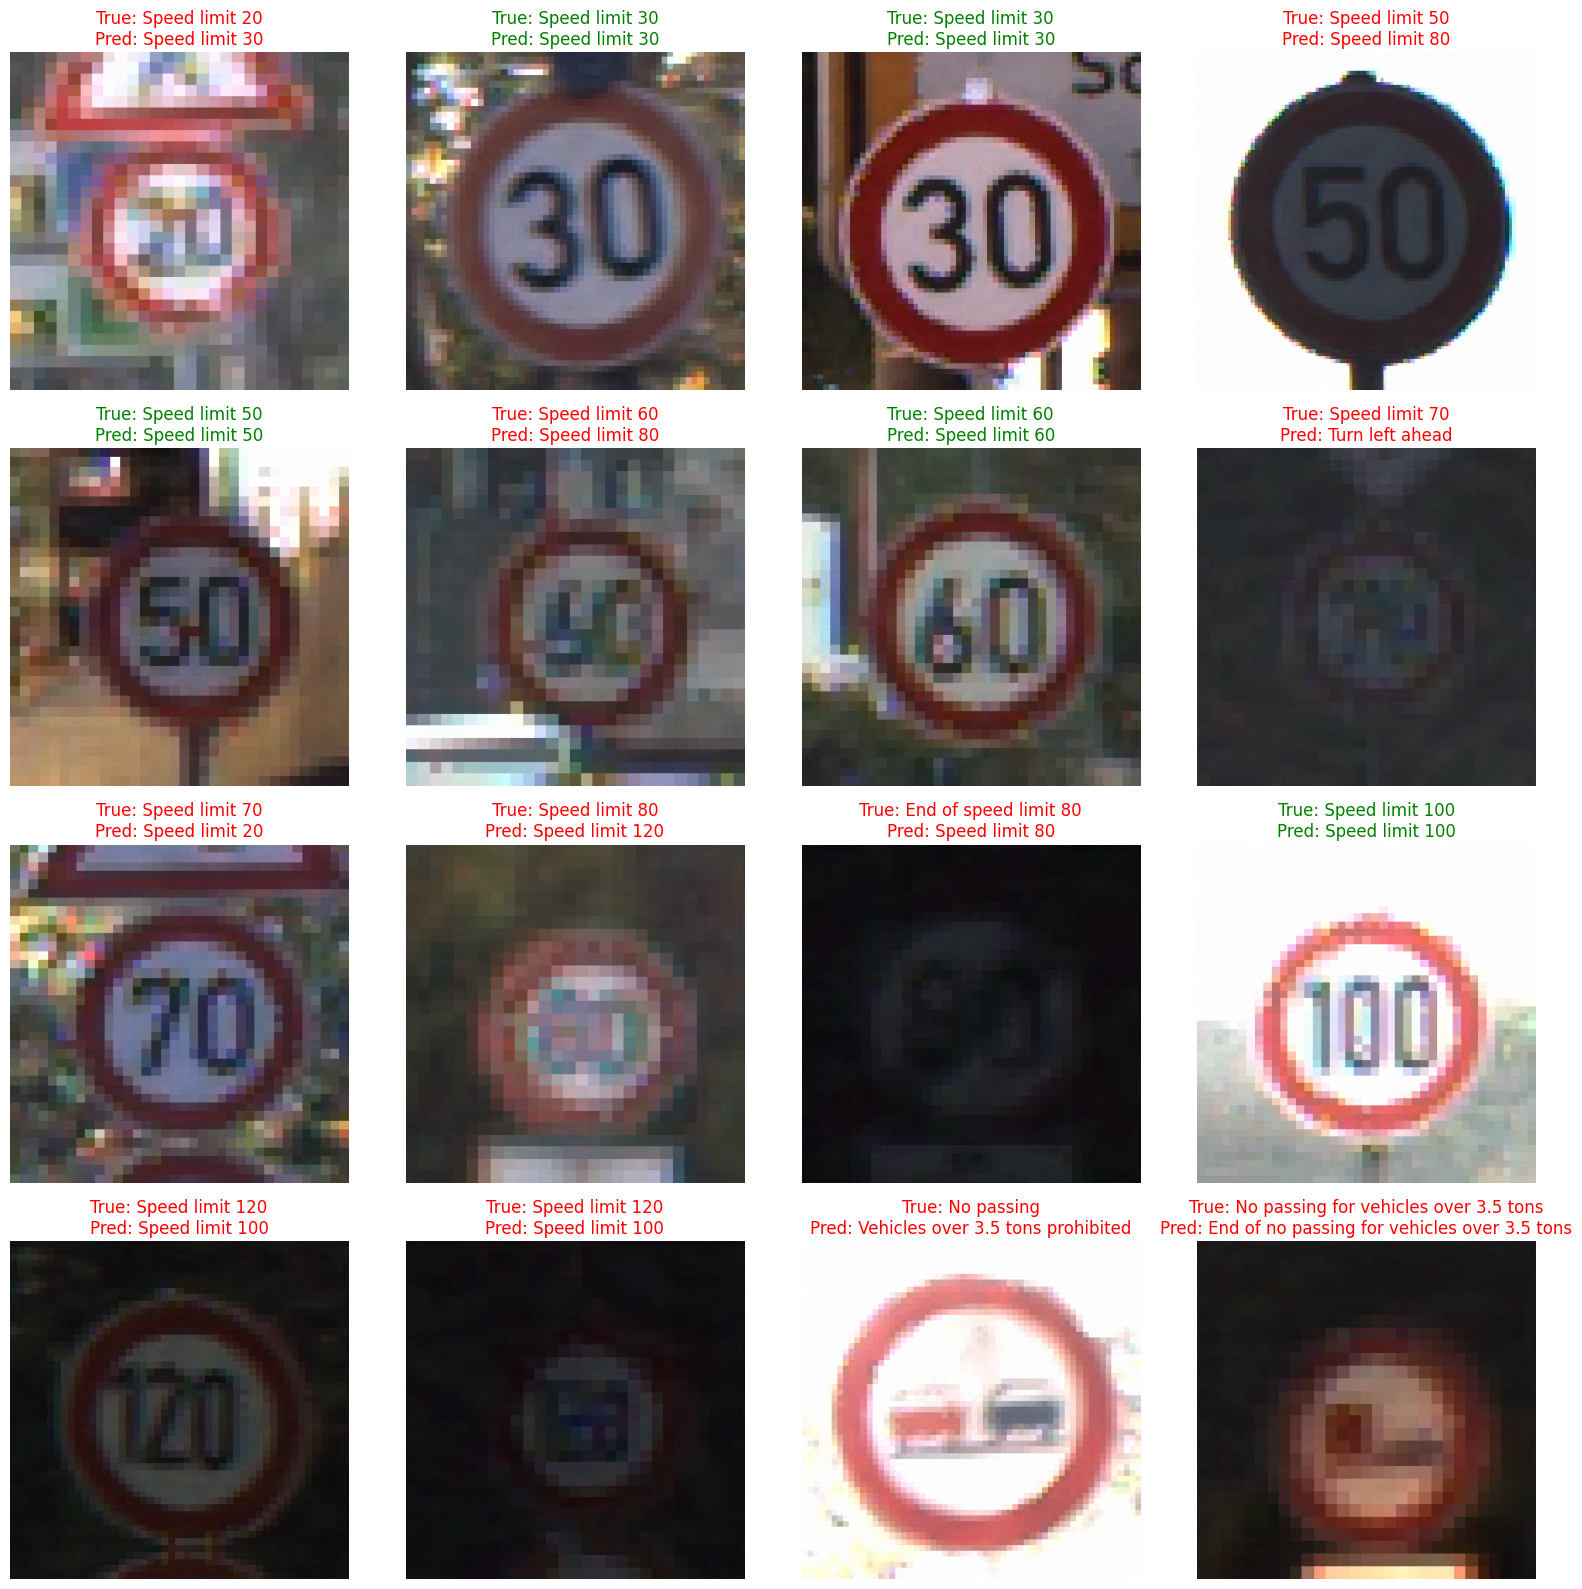

In [ ]:

plt.figure(figsize=(16, 16))

for idx, i in enumerate(range(0, 1600, 100)):  # Adjusted to ensure 16 images
    plt.subplot(4, 4, idx + 1)  # Subplot index starts from 1
    plt.imshow(adv_images[i] / 255)  # Normalize images

    # Check if prediction matches true label
    color = 'green' if pred_labels[i] == GTSRB_CLASSES[true_labels[i]] else 'red'

    # Display prediction in color based on correctness
    plt.title(f'True: {GTSRB_CLASSES[true_labels[i]]}\nPred: {pred_labels[i]}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# PGD
# Set attack strength (adjust as needed)
EPSILON = 0.01
ITERATIONS = 10
ALPHA = EPSILON/ITERATIONS
# Store adversarial images and true labels
adversarial_images = []
true_labels = []

for j in range(len(test_generator)):
    img_batch, label_batch = test_generator[j]  # Get a batch of images and labels
    for i in range(len(img_batch)):
        adv_img = pgd.pgd_attack_single_image(model, img_batch[i], label_batch[i], EPSILON,ALPHA,ITERATIONS,normalized=False)
        adversarial_images.append(adv_img)
        true_labels.append(label_batch[i])

    print(f"Batch {j+1}/{len(test_generator)} completed")

# Convert lists to NumPy arrays for easier processing
adversarial_images = np.array(adversarial_images)
true_labels = np.array(true_labels)

#save the adversarial images
np.savez("adversarial_images_PGD.npz", adversarial_images=adversarial_images, true_labels=true_labels)

Batch 1/123 completed
Batch 2/123 completed
Batch 3/123 completed
Batch 4/123 completed
Batch 5/123 completed
Batch 6/123 completed
Batch 7/123 completed
Batch 8/123 completed
Batch 9/123 completed
Batch 10/123 completed
Batch 11/123 completed
Batch 12/123 completed
Batch 13/123 completed
Batch 14/123 completed
Batch 15/123 completed
Batch 16/123 completed
Batch 17/123 completed
Batch 18/123 completed
Batch 19/123 completed
Batch 20/123 completed
Batch 21/123 completed
Batch 22/123 completed
Batch 23/123 completed
Batch 24/123 completed
Batch 25/123 completed
Batch 26/123 completed
Batch 27/123 completed
Batch 28/123 completed
Batch 29/123 completed
Batch 30/123 completed
Batch 31/123 completed
Batch 32/123 completed
Batch 33/123 completed
Batch 34/123 completed
Batch 35/123 completed
Batch 36/123 completed
Batch 37/123 completed
Batch 38/123 completed
Batch 39/123 completed
Batch 40/123 completed
Batch 41/123 completed
Batch 42/123 completed
Batch 43/123 completed
Batch 44/123 complet

In [ ]:

# Load adversarial images
adversarial_data = np.load("adversarial_images_PGD.npz")
adversarial_images = adversarial_data['adversarial_images']
true_labels = adversarial_data['true_labels']

# Store predictions
predicted_labels = []

# Loop through all adversarial images
for i in range(len(adversarial_images)):
    img = adversarial_images[i]
    img_input = np.expand_dims(img, axis=0)  # Convert to batch format

    # Predict class (assuming you have a similar predict function)
    predicted_class, confidence = predict_traffic_sign(img_input, model, GTSRB_CLASSES)

    # Store results
    predicted_labels.append(predicted_class)

# Convert to NumPy array
predicted_labels = np.array(predicted_labels)



In [ ]:
labels_str =  [GTSRB_CLASSES[label] for label in true_labels]

In [ ]:
np.savez("Adv_predictions.npz", predicted_labels=predicted_labels, true_labels=labels_str)


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print(accuracy_score(labels_str, predicted_labels))

In [ ]:
# Generate classification report
print(classification_report(labels_str, predicted_labels))